In [42]:
import numpy as np
import cvxpy as cp  
import scipy as sp
import matplotlib.pyplot as plt

### Data 
Generate random points from bivariate normal distribution.

In [43]:
n = 50
μ = np.array([0, 0])
Σ = np.array([[5, 4.5], [4.5, 6]])

seed = 1234
rng = np.random.default_rng(seed)
points = rng.multivariate_normal(μ, Σ, size=n)

points

array([[ 3.34006071,  3.82650596],
       [-1.67683016, -1.64781319],
       [-3.96451415, -0.12233844],
       [ 2.42846512,  4.11113951],
       [ 3.26616413,  4.15740405],
       [ 0.10961803,  2.07967606],
       [ 1.43514191,  2.37151477],
       [ 4.25827058,  1.56528723],
       [-2.19163264,  0.11406789],
       [-0.36214638, -1.88633533],
       [-1.13039402, -0.1286668 ],
       [-1.66546402, -3.57201934],
       [-1.72865378, -1.4118367 ],
       [ 0.05877269,  0.0851539 ],
       [ 1.89044278,  1.19465677],
       [-3.00158185, -2.97086456],
       [ 2.84766355, -0.50256512],
       [ 2.22263985,  1.73587255],
       [ 3.68729532,  2.1527693 ],
       [-1.56278282, -2.11155483],
       [ 4.57061262,  3.13253579],
       [-0.18628129,  1.44013836],
       [ 2.0130821 ,  4.60015819],
       [ 2.28639878,  0.02461512],
       [-2.13948635, -0.26560457],
       [-0.00828026,  0.95003672],
       [ 0.67942342,  0.74286445],
       [-4.17537672, -3.34056446],
       [ 0.48279091,

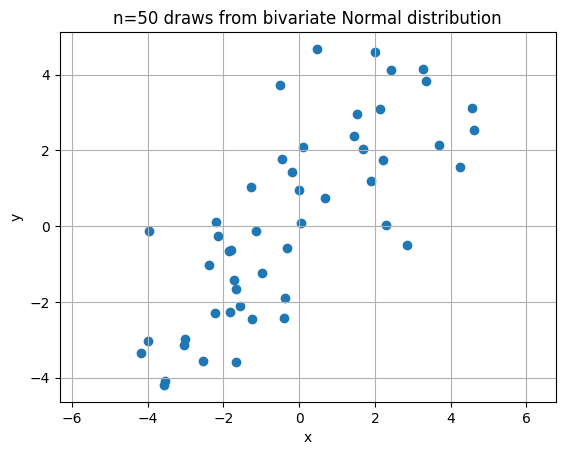

In [44]:
x = points[:, 0]
y = points[:, 1] 
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{n=} draws from bivariate Normal distribution')
plt.axis('equal')
plt.grid()
plt.show()


### Convex hull

Preprocess the data points. The convex hull points are a subset of the data points. We can ignore the points not part of the convex hull.

In [45]:
ipoints2 = sp.spatial.ConvexHull(points).vertices
points2 = points[ipoints2, :]
points2

array([[-3.96451415, -0.12233844],
       [-4.17537672, -3.34056446],
       [-3.56882238, -4.18935073],
       [-1.66546402, -3.57201934],
       [ 2.84766355, -0.50256512],
       [ 4.25827058,  1.56528723],
       [ 4.62461032,  2.53533084],
       [ 4.57061262,  3.13253579],
       [ 3.26616413,  4.15740405],
       [ 2.0130821 ,  4.60015819],
       [ 0.48279091,  4.67870918],
       [-0.49395346,  3.72741355]])

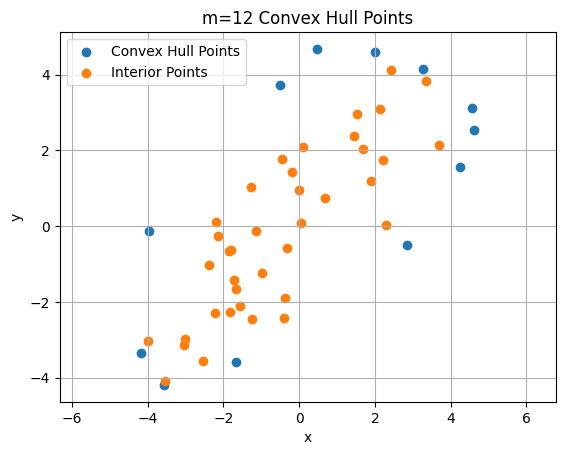

In [46]:
ipoints1  = set([i for i in range(n)])
ipoints2 = set(ipoints2)
ipoints1 = ipoints1 - ipoints2
points1 = points[list(ipoints1), :]

x2 = points2[:, 0]
y2 = points2[:, 1]
m = len(points2) 
plt.scatter(x2, y2, label='Convex Hull Points')
x1 = points1[:, 0]
y1 = points1[:, 1]
plt.scatter(x1, y1, label='Interior Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{m=} Convex Hull Points')
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

## Optimization Model
Model: $$\begin{aligned} \max_{A,b}\> & \log {\bf{det}} A \\ & ||A p_i + b || \le 1 && \forall i \\ & A ⪰ 0\end{aligned}$$
Solve Convex model with CVXPY/SCS. From this perspective the model has $3+2=5$ variables (note that $A$ is symmetric), and $m=9$ constraints. 

In [47]:
d = 2 # dimension of the space
A = cp.Variable((d, d), PSD=True)
b = cp.Variable(d)

constraints = [cp.norm(A @ points2[i] + b) <= 1 for i in range(m)]

objective = cp.Maximize(cp.log_det(A))

prob = cp.Problem(objective, constraints)
prob.solve(verbose=True)

print(f"Optimal objective value: {prob.value}")
print(f"A:\n{A.value}")
print(f"b:\n{b.value}")
center = -np.linalg.inv(A.value) @ b.value
print(f"center:\n{center}")


(CVXPY) Apr 06 05:49:04 PM: Your problem has 6 variables, 12 constraints, and 0 parameters.
(CVXPY) Apr 06 05:49:04 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 06 05:49:04 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 06 05:49:04 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 06 05:49:04 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 06 05:49:04 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 06 05:49:04 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 06 05:49:04 PM: Applying reduction FlipObjective
(CVXPY) Apr 06 05:49:04 PM: Applying reduction Dcp2Cone
(CVXPY) Apr 06 05:49:04 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 06 05:49:04 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 06 05:49:04 PM: Applying reduc

                                     CVXPY                                     
                                     v1.8.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 22, constraints m: 67
cones: 	  l: linear vars: 12
	  q: soc vars: 36, qsize: 12
	  s: psd vars: 13, ssize:

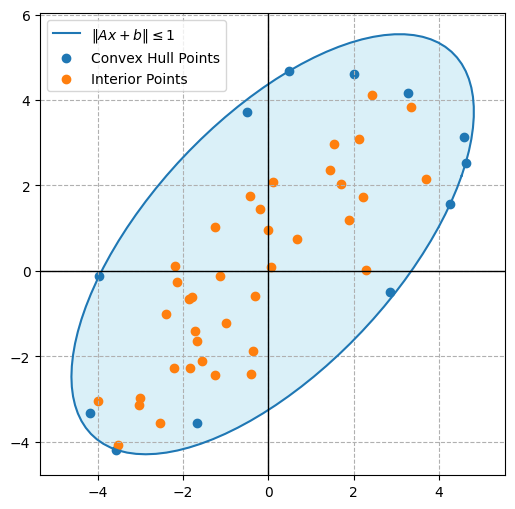

In [48]:
# Generate points 'z' on the unit circle (||z|| = 1)
theta = np.linspace(0, 2*np.pi, 100)
z = np.stack([np.cos(theta), np.sin(theta)])

# Transform z to x: x = A^-1 * (z - b)
# This maps the unit circle boundary to the ellipse boundary
A_inv = np.linalg.inv(A.value)
x = A_inv @ (z - b.value[:, np.newaxis])

# Plot the result
plt.figure(figsize=(6, 6))
plt.plot(x[0, :], x[1, :], label=r'$\|Ax+b\| \leq 1$')
plt.fill(x[0, :], x[1, :], alpha=0.3, color='skyblue') # Fills the interior

# Add the scattered points
plt.scatter(points2[:, 0], points2[:, 1], label='Convex Hull Points')
plt.scatter(points1[:, 0], points1[:, 1], label='Interior Points')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle='--')
plt.axis('equal')
plt.legend()
plt.show()

### Area

$$ {\mathit{Area}} = \frac{\pi}{{\bf{det}}A} $$

In [49]:
area = np.pi / np.linalg.det(A.value)
area

np.float64(56.507094593953205)